In [1]:
import os
import sys
from pathlib import Path
from statsmodels.tsa.ar_model import ar_select_order, AutoReg
import warnings
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats.mstats import winsorize
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

current = Path.cwd().resolve()
repo_root = next((p for p in [current, *current.parents] if (p / 'Empirical').exists() and (p / 'Theory').exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not locate repository root containing 'Empirical' and 'Theory'.")

estimation_dir = repo_root / 'Empirical' / 'estimation'
if str(estimation_dir) not in sys.path:
    sys.path.insert(0, str(estimation_dir))
os.chdir(estimation_dir)

import stage1 as stage1_module
stage1_module.sm = sm

from stage1 import to_ar1_innovations
from grid_search import estimate_single_config

In [2]:
# Structural parameters (same calibration used in theory notebooks)
a = 1.55
gamma = 2.0
sigma = 0.001
delta = 0.9
phi = np.exp(sigma**2 / 2)
kappa = delta * a ** (-gamma) * phi
w = -np.log(kappa) - np.exp(-10)

window_size = 100
n_lags = 1
correct_with_tanh = True
standardize_features = False

print(f'kappa={kappa:.6f}, w={w:.6f}, window={window_size}, standardize={standardize_features}')

kappa=0.374610, w=0.981824, window=100, standardize=False


In [3]:
def extract_best_ar_innovations(topics_df, max_lag=10, ic='aic'):
    """
    Finds the optimal AR(p) model for each time series and extracts the residuals.
    
    Parameters:
    - topics_df: our features including both topics and macro series.
    - max_lag: The maximum number of lags to test (1 to 10).
    - ic: Information criterion to use for selection ('aic' or 'bic').
    """
    # Create an empty DataFrame to store the residuals, keeping the original date index
    innovations = pd.DataFrame(index=topics_df.index)
    
    # Suppress warnings about index frequencies (common with statsmodels)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Loop through each topic column
        for col in topics_df.columns:
            series = topics_df[col].dropna()
            
            # 1. Automatically find the best lag order (p)
            selector = ar_select_order(series, maxlag=max_lag, ic=ic, trend='c')
            best_lags = selector.ar_lags
            
            # Fallback to AR(1) if the algorithm finds no significant lags
            if best_lags is None or len(best_lags) == 0:
                best_lags = [1] 
                
            # 2. Fit the actual AR model using the best lags found
            best_model = AutoReg(series, lags=best_lags, trend='c').fit()
            
            # 3. Extract the residuals (innovations) and assign them back
            innovations[col] = best_model.resid

            # Optional: Print what it found so you can monitor it
            print(f"Topic '{col}': Best model is AR({max(best_lags)})")
            
    return innovations

In [4]:
# Build topic innovations (X candidate)
topics = pd.read_csv(repo_root / 'Empirical' / 'data' / 'macro_topic_data.csv')
# topics = topics[[col for col in topics.columns if not any(char.isdigit() for char in col)]]
topics.set_index('date', inplace=True)
# topics = to_ar1_innovations(topics)
topics = extract_best_ar_innovations(topics)
topics = topics.iloc[1:]
# topics = topics.apply(lambda col: winsorize(col, limits=[0.01, 0.01]))
topics = topics.astype(float)
topics = topics.dropna(axis=0, how='any')

# Standardize topics once, then use the same standardized X in simulation and estimation
if standardize_features:
    scaler_topics = StandardScaler()
    topics = pd.DataFrame(
        scaler_topics.fit_transform(topics),
        index=topics.index,
        columns=topics.columns
    )

# print(f'Topic innovation matrix shape: {topics.shape}')
# print(f'Average variance after preprocessing: {float(topics.var().mean()):.6f}')

Topic 'Fed Funds Effective Rate': Best model is AR(5)
Topic '10-Year Treasury Yield': Best model is AR(1)
Topic '2-Year Treasury Yield': Best model is AR(6)
Topic '10-Year Real Interest Rate': Best model is AR(8)
Topic 'VIX Volatility Index': Best model is AR(8)
Topic 'Financial Stress Index': Best model is AR(10)
Topic 'High Yield Option-Adjusted Spread': Best model is AR(3)
Topic 'BBB Corporate Spread': Best model is AR(10)
Topic 'Trade Weighted USD Index': Best model is AR(9)
Topic '3-Month Treasury Yield': Best model is AR(8)
Topic '30-Year Treasury Yield': Best model is AR(8)
Topic 'TED Spread': Best model is AR(8)
Topic 'WTI Crude Oil': Best model is AR(1)
Topic '10-Year Breakeven Inflation Rate': Best model is AR(6)
Topic 'USD to EUR': Best model is AR(1)
Topic 'USD to JPY': Best model is AR(4)
Topic 'Natural disasters': Best model is AR(10)
Topic 'Internet': Best model is AR(6)
Topic 'Soft drinks': Best model is AR(9)
Topic 'Mobile devices': Best model is AR(7)
Topic 'Profits':

In [5]:
# Lambda calibration: back out lambda from the theoretical stationary distribution of beta.
# For rolling-window OLS with window W, the theory gives:
#   sd_beta = sigma_d * sqrt((1-kappa)/2) / (sigma_x * sqrt(W))
# We set lambda such that a null topic is selected with probability target_selection_prob.
from scipy.stats import norm

target_selection_prob = 0.02
# sigma = 0.02
L = window_size
sigma_x_var_avg = float(topics.var().mean())
sigma_x_for_formula = np.sqrt(sigma_x_var_avg)
sigma_d = sigma

sd_beta = sigma_d * np.sqrt((1.0 - kappa) / 2.0) / (sigma_x_for_formula * np.sqrt(L))
z_crit = norm.ppf(1 - target_selection_prob / 2)
lambda_beta_target = z_crit * sd_beta

d_avg = float((topics.to_numpy() ** 2).mean())
lambda_val = float(lambda_beta_target * d_avg) 

print(f'target_selection_prob = {target_selection_prob}')
print(f'sd_beta               = {sd_beta:.3e}')
print(f'z_crit                = {z_crit:.3f}')
print(f'lambda_beta_target    = {lambda_beta_target:.3e}')
print(f'd_avg                 = {d_avg:.6f}')
print(f'lambda_val (sklearn)  = {lambda_val:.3e}')

target_selection_prob = 0.02
sd_beta               = 3.472e-04
z_crit                = 2.326
lambda_beta_target    = 8.076e-04
d_avg                 = 0.025930
lambda_val (sklearn)  = 2.094e-05


In [6]:
def multivariate_CGL_offline_lasso_with_X(X, sigma, kappa, w, rolling_window_size=300, lambda_lasso=1e-5, correct_with_tanh=False, random_seed=12345):
    """
    Same recursion as Theory/simulate_Lasso.ipynb multivariate_CGL_offline_lasso,
    but takes X as input instead of simulating X internally.
    """
    X = np.asarray(X, dtype=float)
    T, K = X.shape
    assert rolling_window_size < T, 'rolling_window_size must be less than T'

    rng = np.random.default_rng(random_seed)
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    r_offline[1:rolling_window_size + 1] = rng.normal(0, 1e-4, rolling_window_size)

    for t in range(rolling_window_size + 1, T):
        x_current = X[t - rolling_window_size - 1 : t - 1, :]
        r_offline_current = r_offline[t - rolling_window_size : t]

        beta_offline[t, :, 0] = Lasso(
            alpha=lambda_lasso, fit_intercept=False, random_state=42
        ).fit(x_current, r_offline_current).coef_

        pred_tm1 = float(beta_offline[t - 1, :, 0] @ X[t - 1, :])
        pred_t = float(beta_offline[t, :, 0] @ X[t, :])

        if correct_with_tanh:
            r_offline[t] = (
                np.log(1 - kappa * np.exp(w * np.tanh(pred_tm1 / w)))
                - np.log(1 - kappa * np.exp(w * np.tanh(pred_t / w)))
                + rng.normal(0, sigma)
            )
        else:
            r_offline[t] = (
                np.log(1 - kappa * np.exp(pred_tm1))
                - np.log(1 - kappa * np.exp(pred_t))
                + rng.normal(0, sigma)
            )

    return beta_offline, r_offline, X

In [7]:
def run_oracle_test(X_df, label, random_seed, sigma, current_lambda_val):
    X = X_df.to_numpy()

    # Pass current_lambda_val instead of the global lambda_val
    beta_true, y_sim, X_used = multivariate_CGL_offline_lasso_with_X(
        X=X,
        sigma=sigma,
        kappa=kappa,
        w=w,
        rolling_window_size=window_size,
        lambda_lasso=current_lambda_val,
        correct_with_tanh=correct_with_tanh,
        random_seed=random_seed
    )

    # Pass current_lambda_val instead of the global lambda_val
    est = estimate_single_config(
        X=X_used,
        y=y_sim,
        window_size=window_size,
        n_lags=n_lags,
        lambda_val=current_lambda_val,
        standardize=standardize_features,
        verbose=False,
        save_only_positve_r_squared=False,
        return_details=True
    )

    summary = est.get('summary', {})
    details = est['details']
    beta_cols = [c for c in details.columns if c.startswith('Lasso_')]
    beta_est = details[beta_cols].to_numpy()

    beta_true_2d = beta_true[:, :, 0]
    common_t = min(beta_est.shape[0], beta_true_2d.shape[0])
    beta_est_aligned = beta_est[-common_t:, :]
    beta_true_aligned = beta_true_2d[-common_t:, :]

    beta_rmse = float(np.sqrt(np.nanmean((beta_est_aligned - beta_true_aligned) ** 2)))

    n_active_value = np.sum(beta_est != 0)

    out = {
        'label': label,
        'n_obs': int(X_used.shape[0]),
        'n_topics': int(X_used.shape[1]),
        'true_kappa': float(kappa),
        'estimated_kappa': float(summary.get('kappa', np.nan)),
        'kappa_abs_error': float(abs(summary.get('kappa', np.nan) - kappa)) if not np.isnan(summary.get('kappa', np.nan)) else np.nan,
        'kappa_tstat': float(summary.get('kappa_tstat', np.nan)),
        'stage1_r2_oos': float(summary.get('r2_oos_stage1', np.nan)),
        'stage2_r2_oos': float(summary.get('r2_oos_stage2', np.nan)),
        'stage1_r2_insample': float(summary.get('r2_insample_stage1', np.nan)),
        'stage2_r2_insample': float(summary.get('r2_insample_stage2', np.nan)),
        'beta_rmse': beta_rmse,
        'n_active_stage1': float(n_active_value) if not np.isnan(n_active_value) else np.nan
    }

    return out, details, beta_true

In [8]:
# this function calculates lambda based on the value of sigma for a given target_selection_prob
# as lambda scales linearly with sigma, the model will yield very similiar results that differ mostly (only?) in the randomness of the seed

def calculate_lambda(current_sigma, kappa, window_size, topics_df, target_selection_prob=0.02):
    sigma_x_var_avg = float(topics_df.var().mean())
    sigma_x_for_formula = np.sqrt(sigma_x_var_avg)
    
    # sd_beta scales linearly with the provided sigma (sigma_d)
    sd_beta = current_sigma * np.sqrt((1.0 - kappa) / 2.0) / (sigma_x_for_formula * np.sqrt(window_size))
    z_crit = norm.ppf(1 - target_selection_prob / 2)
    lambda_beta_target = z_crit * sd_beta

    d_avg = float((topics_df.to_numpy() ** 2).mean())
    lambda_val = float(lambda_beta_target * d_avg) 
    
    return lambda_val

In [9]:
# # Define your range of sigma values
# # This function runs the simulation for a fixed sigma and lambda value and a set of 100 random seeds each

# # select sigma from distribution centered around value selected
# # check if ar1 is good or some other ar model
# # add controls / econ ts
# # choose lambda to match 2nd stage r2 is oos

# sigma_values = [0.001, 0.01, 0.1, 0.0001]
# n_seeds = 100

# all_summaries = []
# all_details = []
# all_beta_trues = []

# print(f"Starting oracle tests for {len(sigma_values)} sigma values and {n_seeds} seeds each...")

# for sigma in sigma_values:
#     print(f"Processing sigma = {sigma}...")
    
#     # 1. Adapt lambda for the current sigma
#     current_lambda_val = calculate_lambda(
#         current_sigma=sigma, 
#         kappa=kappa, 
#         window_size=window_size, 
#         topics_df=topics
#     )
#     print(f"  -> Calculated lambda_val = {current_lambda_val:.3e}")
    
#     for seed in range(n_seeds):
#         # 2. Pass the adapted lambda into the test
#         summary_dict, details_df, b_true = run_oracle_test(
#             topics, 
#             label='estimation_', 
#             random_seed=seed, 
#             sigma=sigma,
#             current_lambda_val=current_lambda_val
#         )
        
#         # Track metadata in the summary dictionary
#         summary_dict['seed'] = seed
#         summary_dict['sigma'] = sigma
        
#         all_summaries.append(summary_dict)
#         all_details.append(details_df)
#         all_beta_trues.append(b_true)

# # 1. results becomes a DataFrame of the metrics
# results_df = pd.DataFrame(all_summaries)

# # 2. Lists containing the full DataFrames/Arrays for each run
# details_list = all_details
# beta_true_list = all_beta_trues

# print("Tests complete.")
# print(f"Total metrics shape: {results_df.shape}")

# # save results to disk
# output_dir = repo_root / 'Empirical' / 'results' / 'oracle_tests'
# output_dir.mkdir(parents=True, exist_ok=True)
# results_df.to_csv(output_dir / 'oracle_test_results.csv', index=False)

In [10]:
import numpy as np
import pandas as pd
# # This function runs the simulation for a varying sigma value around a center and a fixed lambda value for each base sigma and a set of 100 random seeds each

# Define your range of base sigma values
base_sigma_values = [0.001, 0.01, 0.1]
n_seeds = 5

# Control how narrow the distribution is (e.g., 0.01 = 1% standard deviation)
sigma_noise_fraction = 0.1

all_summaries = []
all_details = []
all_beta_trues = []

print(f"Starting oracle tests for {len(base_sigma_values)} base sigma values and {n_seeds} seeds each...")

for base_sigma in base_sigma_values:
    print(f"Processing base sigma = {base_sigma}...")
    
    # 1. Adapt lambda for the current base sigma ONCE
    current_lambda_val = calculate_lambda(
        current_sigma=base_sigma, 
        kappa=kappa, 
        window_size=window_size, 
        topics_df=topics
    )
    print(f"  -> Calculated lambda_val = {current_lambda_val:.3e}")
    
    for seed in range(n_seeds):
        # Set numpy seed so the random sigma draw is reproducible for this specific run
        np.random.seed(seed)
        
        # 2. Draw sigma from a very narrow distribution around the base_sigma
        drawn_sigma = np.random.normal(loc=base_sigma, scale=base_sigma * sigma_noise_fraction)
        
        # Safety constraint to prevent zero or negative sigmas
        drawn_sigma = max(drawn_sigma, 1e-8)
        
        # 3. Pass the adapted lambda and the newly DRAWN sigma into the test
        summary_dict, details_df, b_true = run_oracle_test(
            topics, 
            label='estimation_', 
            random_seed=seed, 
            sigma=drawn_sigma, # <--- Using the drawn sigma here
            current_lambda_val=current_lambda_val
        )
        
        # Track metadata in the summary dictionary
        summary_dict['seed'] = seed
        summary_dict['base_sigma'] = base_sigma
        summary_dict['drawn_sigma'] = drawn_sigma # Record the exact sigma used for this run
        
        all_summaries.append(summary_dict)
        all_details.append(details_df)
        all_beta_trues.append(b_true)

# 1. results becomes a DataFrame of the metrics
results_df = pd.DataFrame(all_summaries)

# 2. Lists containing the full DataFrames/Arrays for each run
details_list = all_details
beta_true_list = all_beta_trues

print("Tests complete.")
print(f"Total metrics shape: {results_df.shape}")

# save results to disk
output_dir = repo_root / 'Empirical' / 'results' / 'oracle_tests'
output_dir.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_dir / 'oracle_test_results.csv', index=False)

Starting oracle tests for 3 base sigma values and 5 seeds each...
Processing base sigma = 0.001...
  -> Calculated lambda_val = 2.094e-05
Processing base sigma = 0.01...
  -> Calculated lambda_val = 2.094e-04
Processing base sigma = 0.1...
  -> Calculated lambda_val = 2.094e-03
Tests complete.
Total metrics shape: (15, 16)


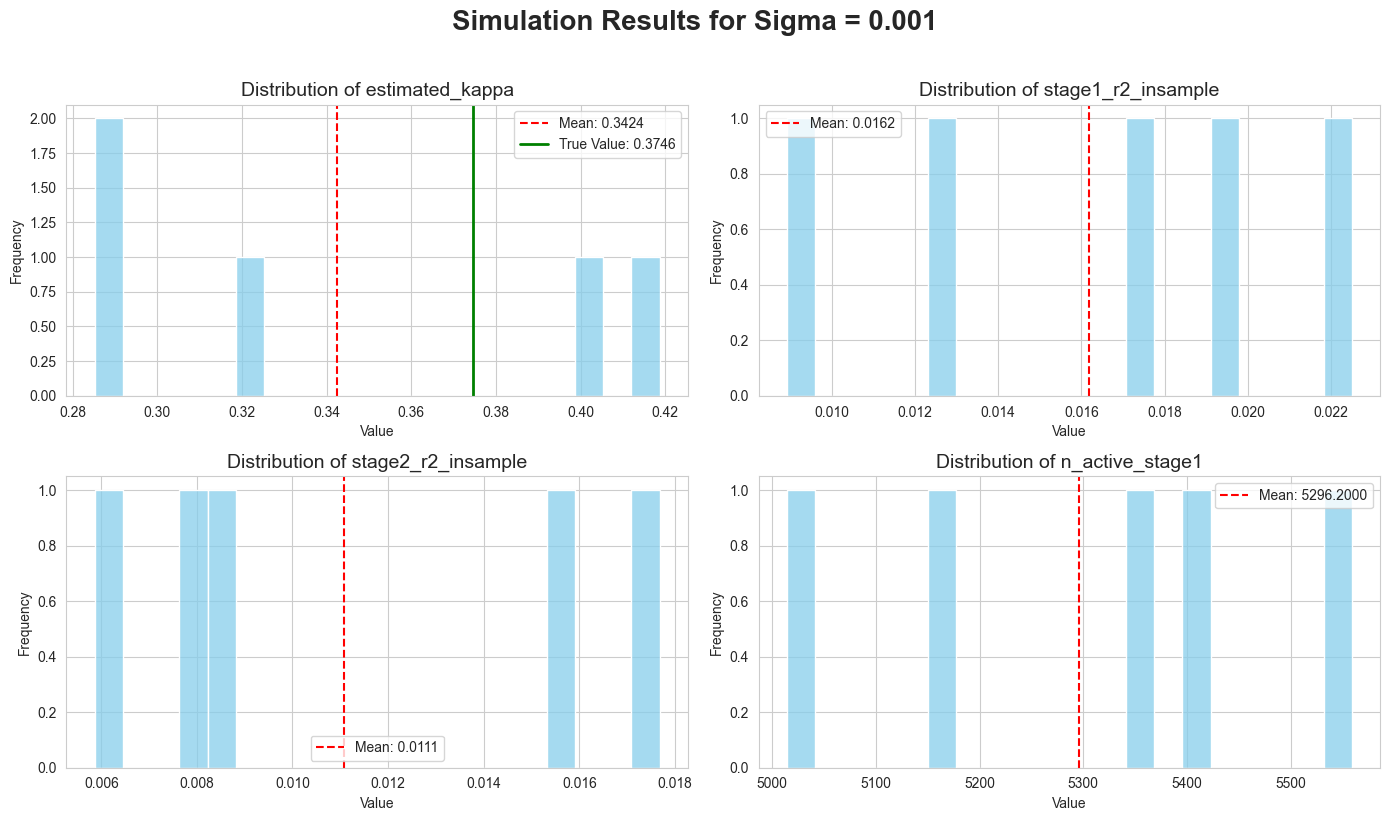

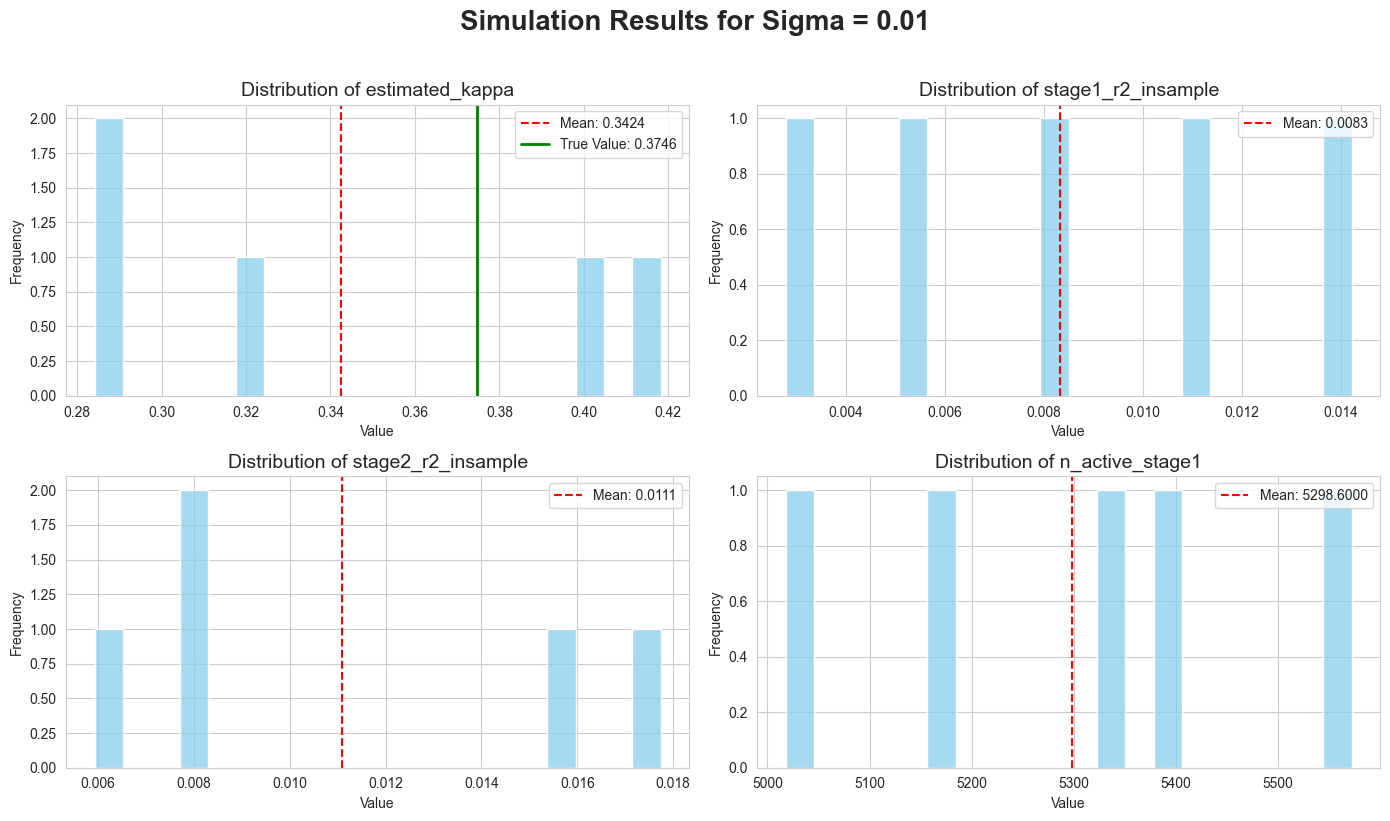

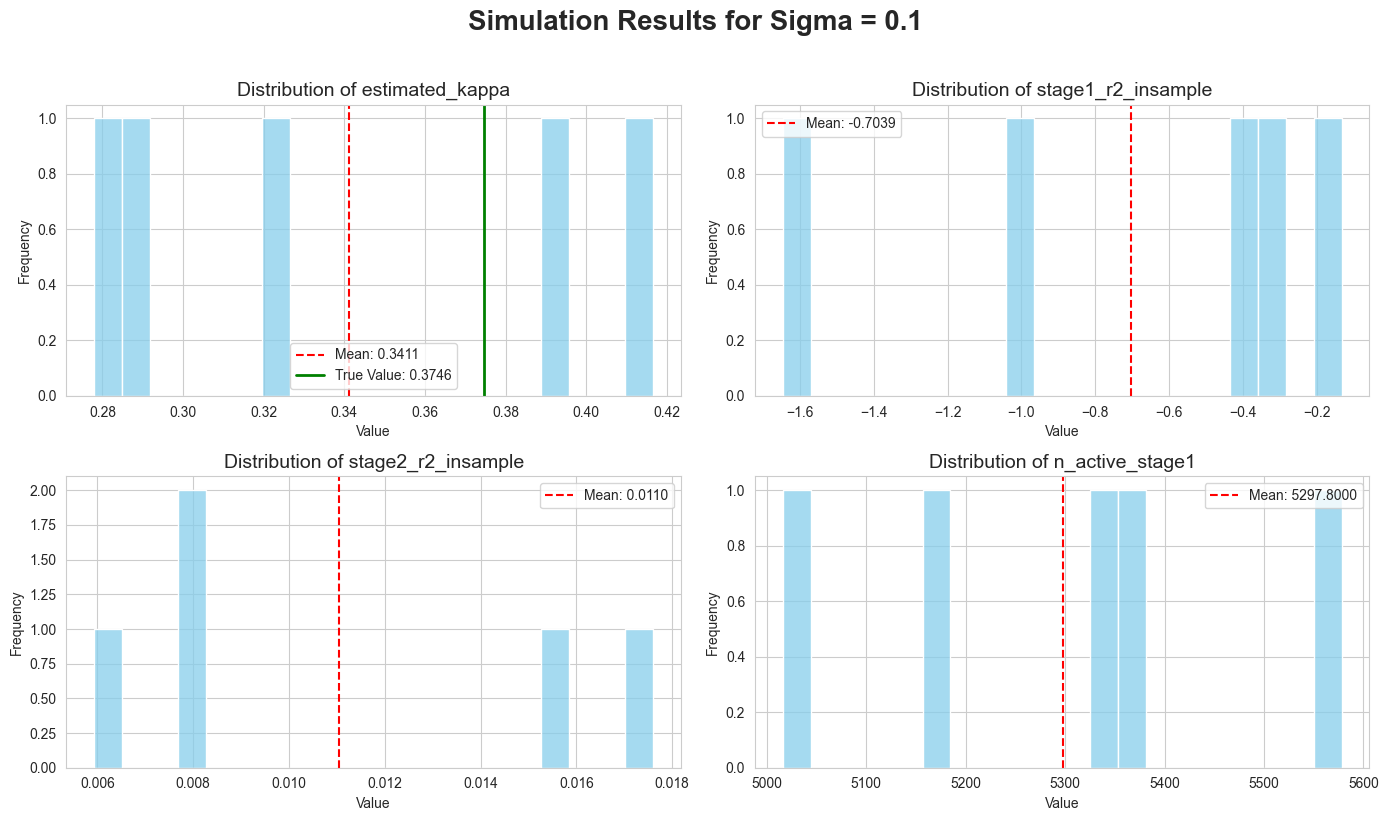

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the columns we want to visualize
metrics_to_plot = [
    'estimated_kappa', 'stage1_r2_insample', 
    'stage2_r2_insample', 
    'n_active_stage1'
]

# 2. Set up the grid dimensions
n_cols = 2
n_rows = int(np.ceil(len(metrics_to_plot) / n_cols))

sns.set_style("whitegrid")

# 3. Iterate over each unique sigma value in the results
# Ensure 'sigma' exists in your dataframe. Sort them so they plot in order.
unique_sigmas = sorted(results_df['base_sigma'].unique())

for sigma_val in unique_sigmas:
    # Filter the dataframe for the current sigma only
    subset_df = results_df[results_df['base_sigma'] == sigma_val]
    
    # Create a new figure for the current sigma
    plt.figure(figsize=(14, 4 * n_rows))
    
    for i, col in enumerate(metrics_to_plot):
        if col not in subset_df.columns:
            continue
            
        ax = plt.subplot(n_rows, n_cols, i + 1)
        
        # Plot histogram using the subset data
        # We drop NaNs to avoid plotting errors if a metric failed to calculate
        plot_data = subset_df[col].dropna()

        # if 'r2' in col.lower(): 
        #     plot_data = plot_data[plot_data >= 0]
        
        if len(plot_data) == 0:
            continue
            
        sns.histplot(plot_data, kde=False, color="skyblue", bins=20)
        
        # Add a vertical line for the mean
        mean_val = plot_data.mean()
        plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
        
        # Special Case: Highlight the True Kappa if plotting estimated_kappa
        if col == 'estimated_kappa' and 'true_kappa' in subset_df.columns:
            true_k = subset_df['true_kappa'].iloc[0]
            plt.axvline(true_k, color='green', linestyle='-', linewidth=2, label=f'True Value: {true_k:.4f}')
        
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend()

    # Add a main title for the entire figure to indicate the sigma value
    plt.suptitle(f'Simulation Results for Sigma = {sigma_val}', fontsize=20, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show() 

In [12]:
# now load return data and plot the same metrics for real data to compare with the simulation results
returns = pd.read_csv(repo_root / 'Empirical' / 'data' / 'X.csv')
returns.set_index('date', inplace=True)
# keep only columns where colname is a number
returns = returns[[col for col in returns.columns if any(char.isdigit() for char in col)]]
returns = returns.astype(float)

In [13]:
# Assuming `returns_df` is defined and shares the same datetime index as `topics`.
# Let's select a subset of columns (e.g., the first 10, or a specific list of tickers)
tickers_to_run = returns.columns[0:40] 

# compue the average standard deviation of tickers_to_run
avg_std = returns[tickers_to_run].std().mean()
print(f'Average standard deviation of selected tickers: {avg_std:.6f}')

empirical_summaries = []
empirical_details = {} # Storing details in a dictionary keyed by ticker for easy access

print(f"Starting empirical estimation for {len(tickers_to_run)} assets...")

for ticker in tickers_to_run:
    # 1. Extract and align the target variable (y)
    y_empirical = returns[ticker]
    
    # Ensure y and X are aligned, dropping any dates where the stock has missing returns
    valid_idx = y_empirical.dropna().index.intersection(topics.index)
    X_used = topics.loc[valid_idx].to_numpy()
    y_used = y_empirical.loc[valid_idx].to_numpy()


    # 2. Run the estimation pipeline
    est = estimate_single_config(
        X=X_used,
        y=y_used,
        window_size=100,
        n_lags=1,
        lambda_val=4.188e-04,
        standardize=standardize_features,
        verbose=True,
        save_only_positve_r_squared=False,
        return_details=True
    )
    
    # 3. Extract and format the results
    summary = est.get('summary', {})
    details = est['details']
    
    # track active topics
    beta_cols = [c for c in details.columns if c.startswith('Lasso_')]
    if beta_cols:
        beta_est = details[beta_cols].to_numpy()
        n_active_value = np.sum(beta_est != 0)
    else:
        n_active_value = np.nan
        
    # Build a clean dictionary for this ticker
    out = {
        'ticker': ticker,
        'n_obs': int(X_used.shape[0]),
        'n_topics': int(X_used.shape[1]),
        'estimated_kappa': float(summary.get('kappa', np.nan)),
        'kappa_tstat': float(summary.get('kappa_tstat', np.nan)),
        'stage1_r2_oos': float(summary.get('r2_oos_stage1', np.nan)),
        'stage2_r2_oos': float(summary.get('r2_oos_stage2', np.nan)),
        'stage1_r2_insample': float(summary.get('r2_insample_stage1', np.nan)),
        'stage2_r2_insample': float(summary.get('r2_insample_stage2', np.nan)),
        'n_active_stage1': float(n_active_value) if not np.isnan(n_active_value) else np.nan
    }
    
    empirical_summaries.append(out)
    empirical_details[ticker] = details

# 4. Compile into a final DataFrame
empirical_results_df = pd.DataFrame(empirical_summaries)

print("Empirical estimation complete.")
display(empirical_results_df.head())

Average standard deviation of selected tickers: 0.020694
Starting empirical estimation for 40 assets...
Empirical estimation complete.


,ticker,n_obs,n_topics,estimated_kappa,kappa_tstat,stage1_r2_oos,stage2_r2_oos,stage1_r2_insample,stage2_r2_insample,n_active_stage1
0,10065,1879,196,2.762348e-01,5.862866e+00,0.006627,0.043607,0.031203,1.007550e-02,3563.0
1,10145,1879,196,3.264040e-06,3.051869e-05,-0.054528,-0.000109,0.027277,-6.001392e-08,4276.0
2,10294,1879,196,4.585052e-09,5.598089e-08,-0.051545,-0.000664,0.036222,-2.350031e-11,5654.0
3,10375,1879,196,1.344099e-01,1.743467e+00,-0.031934,-0.003966,0.032141,1.297272e-03,5133.0
4,10516,1879,196,9.769852e-02,1.174813e+00,-0.028816,-0.000429,0.028779,6.355836e-04,4877.0


Number of assets with kappa t-stat > 1.9: 10 out of 40


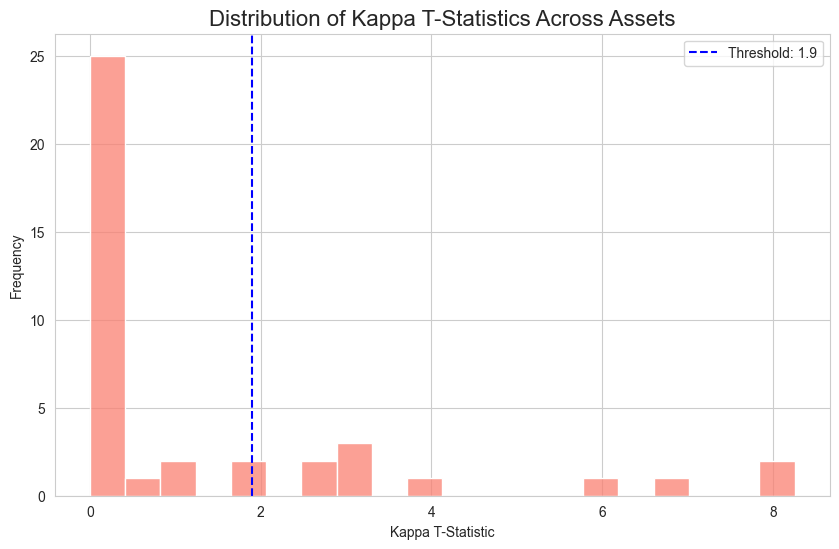

In [14]:
import seaborn as sns

# count the number of t-stats greater than 1.9
empirical_summaries_df = pd.DataFrame(empirical_summaries)
num_significant_kappas = (empirical_summaries_df['kappa_tstat'] > 1.9).sum()
print(f"Number of assets with kappa t-stat > 1.9: {num_significant_kappas} out of {len(empirical_summaries_df)}")

# print histogram of t-stats
plt.figure(figsize=(10, 6))
sns.histplot(empirical_summaries_df['kappa_tstat'].dropna(), bins=20, kde=False, color="salmon")
plt.axvline(1.9, color='blue', linestyle='--', label='Threshold: 1.9')
plt.title('Distribution of Kappa T-Statistics Across Assets', fontsize=16)
plt.xlabel('Kappa T-Statistic')
plt.ylabel('Frequency')
plt.legend()
plt.show()

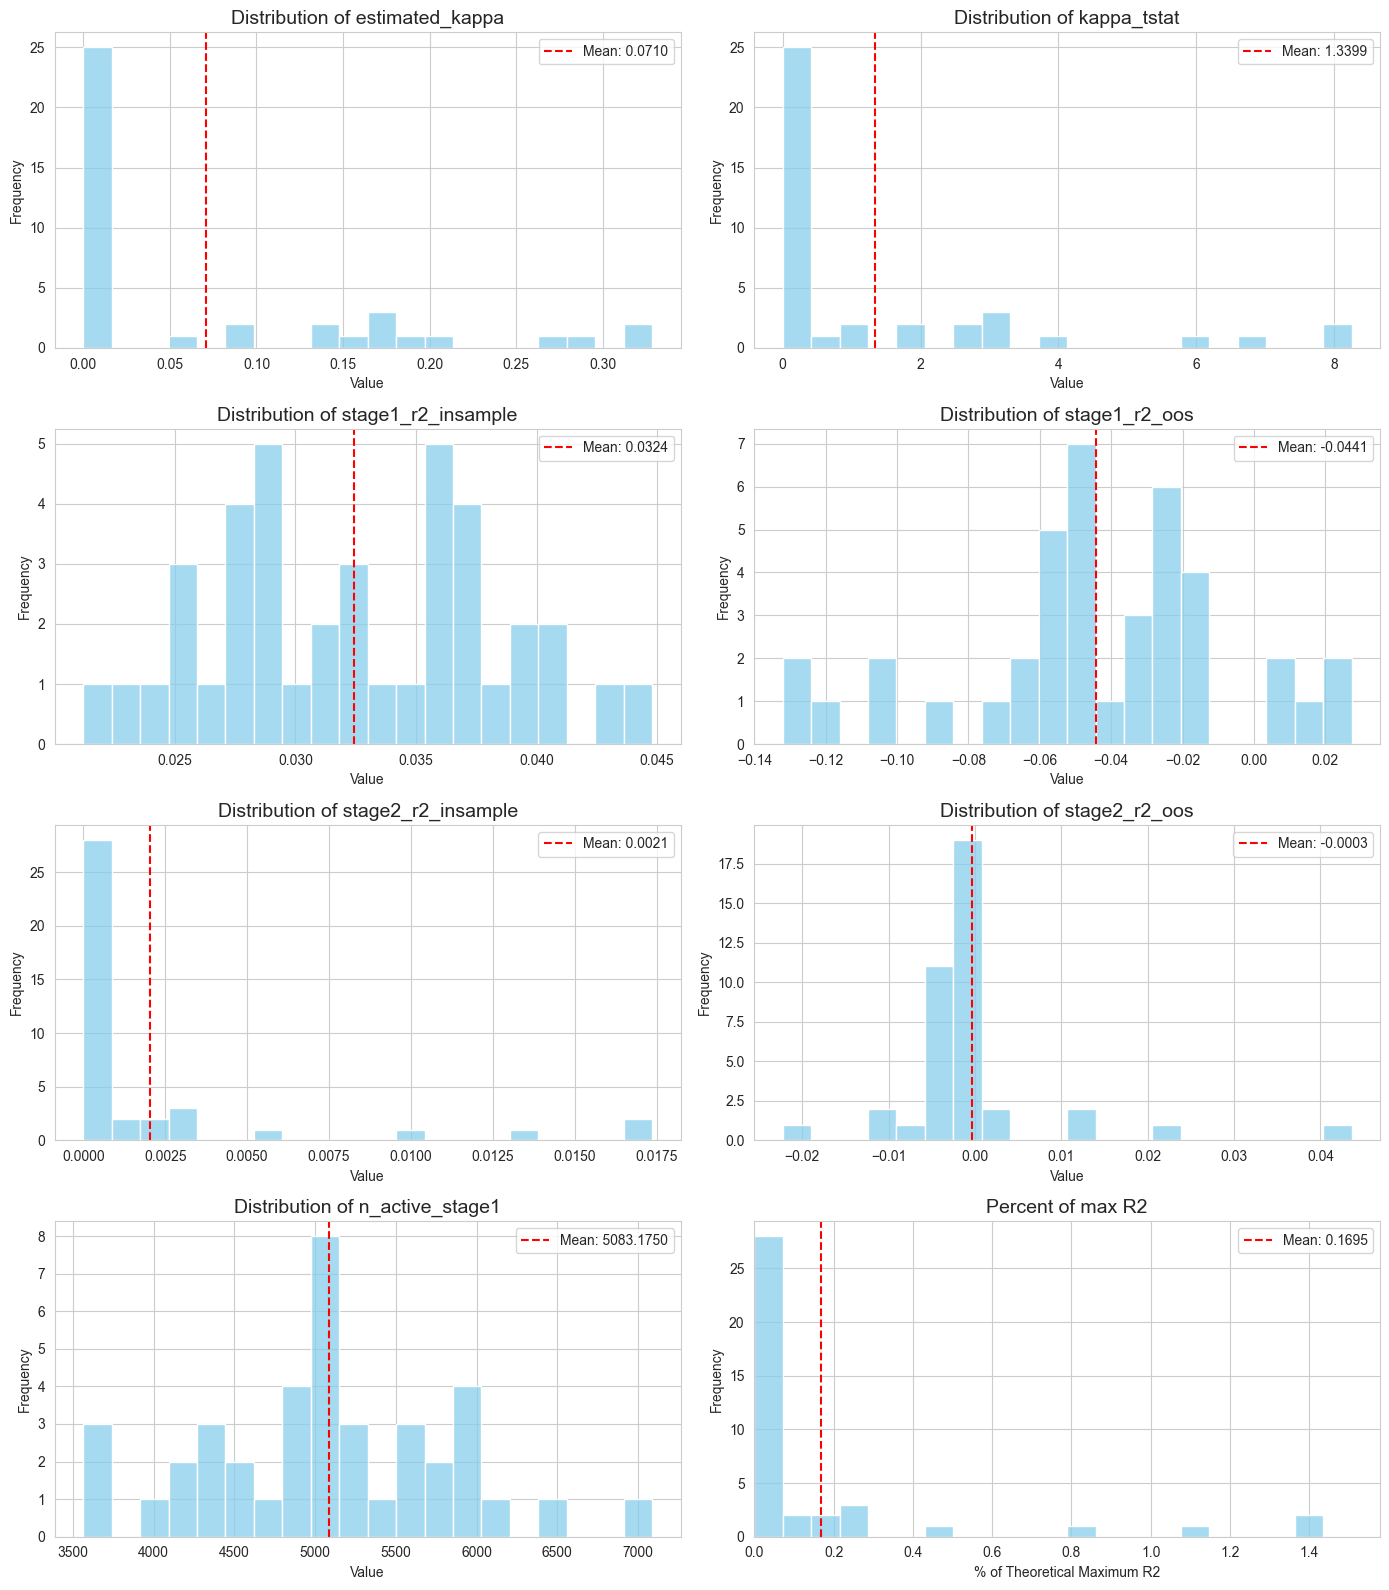

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the Theoretical Benchmark 
mean_theoretical_r2 = 0.0121

# Calculate the percentage of the signal captured
empirical_results_df['signal_captured_pct'] = (empirical_results_df['stage2_r2_insample'] / mean_theoretical_r2)

# if signal captured is negative, set to 0
empirical_results_df['signal_captured_pct'] = empirical_results_df['signal_captured_pct'].apply(lambda x: max(x, 0))

# set values above 3 to 0

# 2. Define the metrics for visualization
metrics_to_plot = [
    'estimated_kappa', 'kappa_tstat', 
    'stage1_r2_insample', 'stage1_r2_oos',
    'stage2_r2_insample', 'stage2_r2_oos',
    'n_active_stage1', 'signal_captured_pct'
]

n_cols = 2
n_rows = int(np.ceil(len(metrics_to_plot) / n_cols))

plt.figure(figsize=(14, 4 * n_rows))
sns.set_style("whitegrid")

for i, col in enumerate(metrics_to_plot):
    if col not in empirical_results_df.columns:
        continue
        
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(empirical_results_df[col], kde=False, color="skyblue", bins=20)
    
    mean_val = empirical_results_df[col].mean()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.4f}')
    
    # Dynamic X-Scale for Signal Captured
    if col == 'signal_captured_pct':
        max_captured = empirical_results_df['signal_captured_pct'].max()
        x_limit = 100 if max_captured > 90 else max_captured * 1.1
        plt.xlim(0, x_limit)
        
        plt.title('Percent of max R2', fontsize=14)
        plt.xlabel('% of Theoretical Maximum R2')
    else:
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel('Value')
        
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# save results to csv
empirical_results_df.to_csv(repo_root / 'Empirical' / 'data' / 'oracle_test_empirical_results.csv', index=False)